Programma Chiara Righi

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root
from scipy.special import kv  # Bessel K

# ==========================================================
# COSTANTI
# ==========================================================
ALFA = 0.3
RMIN = 3.0
RMAX = 1000.0
DELTA = 0.0

C1 = 0.5
C3 = 0.3
TNORM = 1.68e-10

In [28]:
# ==========================================================
# FUNZIONI MATEMATICHE
# ==========================================================
def bessk(n, x):
    return kv(n, x)


def g(teta):
    return (1.0 / bessk(2, 1.0 / teta)) * (2.0 + 2.0 * teta + 1.0 / teta) * np.exp(-1.0 / teta)

In [29]:
# ==========================================================
# SISTEMA NON LINEARE
# ==========================================================

def temperat(y, mdot, m, beta):

    ff = y[2]**2
    xm = 1e3 * y[1]**2
    teta = y[0]**2

    s1 = 1.42e9 * ALFA**(-0.5) * np.sqrt(1 - beta) * C1**(-0.5) * C3**0.5
    s2 = 1.19e-13 * xm

    # --- Heating ---
    q1 = 1.2e4 * g(teta) * ALFA**(-2) * C1**(-2) * C3 * beta * m * mdot**2 / RMIN
    q2 = DELTA * 9.39e4 * ((1 - beta) / ff) * C3 * m * mdot / RMIN
    q = q1 + q2

    # --- Synchrotron ---
    nup = s1 * s2 * m**(-0.5) * mdot**0.5 * (teta / TNORM)**2 * RMIN**(-5/4)

    psinc = (
        53.0 * (xm / 1000.0)**3 *
        (teta / (1e9 * TNORM))**7 *
        m**0.5 * mdot**1.5
    )

    # --- Compton ---
    abig = 1 + 4*teta + 16*teta**2
    tau = 23.87 * mdot
    alfac = -np.log(tau) / np.log(abig)

    graffa = ((6.2e7 * (teta / (1e9 * TNORM))) / (nup * 1e-12))**(1 - alfac) - 1
    pcomp = (psinc / 0.71) / (1 - alfac) * graffa

    # --- Brems ---
    if teta < 1:
        f = 4*np.sqrt(2*teta/np.pi**3)*(1 + 1.781*teta**1.34)
    else:
        f = (9*teta/(2*np.pi))*(np.log(1.123*teta + 0.48) + 1.5)

    pbrems = 4.78 * ALFA**(-2) * C1**(-2) * np.log(RMAX/RMIN) * f * m * mdot**2

    # --- Equazioni ---
    f1 = q - psinc - pcomp - pbrems
    f2 = (1 - ff)*9.39e4*((1 - beta)/ff)*C3*m*mdot/RMIN - q

    vv = xm**(1/3)
    f3 = (
        vv + 1.852*np.log(vv)
        - 10.36
        - 0.26*np.log(m*mdot)
        + 0.26*np.log(teta**3 * bessk(2, 1/teta))
    )

    return [f1, f3, f2]

In [30]:
# ==========================================================
# SPETTRO
# ==========================================================

def spectrum(te, f, xm, m, mdot, beta, savefile='prova.txt'):

    numin = 1e10
    numax = 1e21
    num = 100

    lnu = np.linspace(np.log10(numin), np.log10(numax), num)
    nu = 10**lnu

    teta = 1.68e-10 * te

    s1 = 1.42e9 * ALFA**(-0.5) * np.sqrt(1 - beta) * C1**(-0.5) * C3**0.5
    s2 = 1.19e-13 * xm
    s3 = 1.05e-24

    abig = 1 + 4*teta + 16*teta**2
    tau = 23.87 * mdot
    alfac = -np.log(tau) / np.log(abig)

    lnup = np.log10(s1*s2*m**(-0.5)*mdot**0.5*te**2 * RMIN**(-5/4))
    lnucmax = np.log10(te) + 10.796

    # coefficiente sinc
    llsinc = (
        3*np.log10(s1*s2)
        + np.log10(s3)
        - (7/4)*np.log10(RMIN)
        + np.log10(m**0.5 * mdot**1.5)
        + 7*np.log10(te)
    )

    lls = np.zeros(num)
    llc = np.zeros(num)
    llb = np.zeros(num)

    for i in range(num):

        # ---------------- SYNCHROTRON ----------------
        if lnu[i] < lnup:
            lls[i] = (
                np.log10(s3)
                + (8/5)*np.log10(s1*s2)
                + np.log10(m**(6/5) * mdot**(4/5))
                + (21/5)*np.log10(te)
                + (2/5)*lnu[i]
            )
        else:
            lls[i] = 0.0

        # ---------------- COMPTON ----------------
        if lnu[i] > lnup:

            base = llsinc + (alfac - 1)*lnup - alfac*lnu[i]
            cutoff = -(10**(lnu[i] - lnucmax)) / np.log(10)
            llc[i] = base + cutoff

        else:
            llc[i] = 0.0

        # ---------------- BREMS ----------------
        if teta < 1:
            fb = 4*np.sqrt(2*teta/np.pi**3)*(1 + 1.781*teta**1.34)
        else:
            fb = (9*teta/(2*np.pi))*(np.log(1.123*teta + 0.48) + 1.5)

        base_b = (
            24.36
            - 2*np.log10(ALFA*C1)
            + np.log10(np.log(RMAX/RMIN) * fb)
            - np.log10(te)
            + np.log10(m * mdot**2)
        )

        cutoff_b = -(4.8e-11 * nu[i] / te) / np.log(10)
        llb[i] = base_b + cutoff_b

    flux = 10**lls + 10**llc + 10**llb
    y = lnu + np.log10(flux)

    # -------- OUTPUT --------
    for i in range(num):
        print(lnu[i], y[i])

    # -------- FILE --------
    if savefile:
        np.savetxt(savefile, np.column_stack([lnu, y]))
        print(f"\nFile salvato: {savefile}")

    # -------- PLOT --------
    plt.figure()
    plt.plot(lnu, y, linewidth=2)
    plt.xlabel("log ν")
    plt.ylabel("log νFν")
    plt.title("ADAF spectrum")
    plt.grid()
    plt.show()

In [31]:
# ==========================================================
# specdata
# ==========================================================

def specdata(m, mdot, beta):

    print(f"m = {m}")
    print(f"mdot = {mdot}")

    y0 = [0.5, 1.0, 0.99]

    sol = root(temperat, y0, args=(mdot, m, beta), tol=1e-10)

    if not sol.success:
        print("Non converge")

    y = sol.x

    teta = y[0]**2
    te = teta / 1.68e-10
    xm = 1e3 * y[1]**2
    f = y[2]**2

    print("\n=== OUTPUT ===")
    print("teta =", te)
    print("xm   =", xm)
    print("f    =", f)

    spectrum(te, f, xm, m, mdot, beta, 'prova.txt')

m = 1000000000.0
mdot = 0.0057

=== OUTPUT ===
teta = 3793614474.704159
xm   = 1178.3413966349508
f    = 0.9404787352796324
10.0 38.13648316005373
10.11111111111111 38.2920386905896
10.222222222222221 38.44759422355925
10.333333333333334 38.60314975872594
10.444444444444445 38.758705295875956
10.555555555555555 38.91426083481636
10.666666666666666 39.069816375373
10.777777777777779 39.22537191738866
10.88888888888889 39.38092746072141
11.0 39.53648300524313
11.11111111111111 39.69203855083816
11.222222222222221 39.84759409740211
11.333333333333334 40.00314964484071
11.444444444444445 40.15870519306888
11.555555555555555 40.31426074200983
11.666666666666666 40.469816291594206
11.777777777777779 40.62537184175943
11.88888888888889 40.780927392449
12.0 40.93648294361191
12.11111111111111 41.092038495202104
12.222222222222221 41.24759404717804
12.333333333333332 41.28355069601881
12.444444444444445 41.298610225034686
12.555555555555555 41.31366975613519
12.666666666666666 41.32872928982157

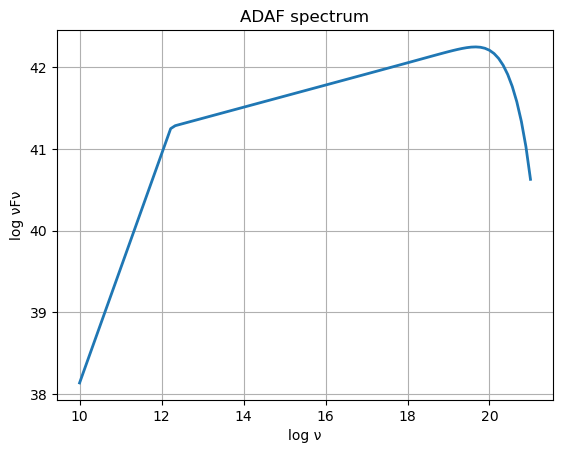

m = 1000000000.0
mdot = 0.0005

=== OUTPUT ===
teta = 5532891923.712361
xm   = 875.342101357739
f    = 0.9965085391350555
10.0 37.77278548996348
10.11111111111111 37.92834104503112
10.222222222222221 38.08389660014622
10.333333333333334 38.23945215530417
10.444444444444445 38.39500771050079
10.555555555555555 38.55056326573233
10.666666666666666 38.706118820995385
10.777777777777779 38.8616743762869
10.88888888888889 39.01722993160409
11.0 39.17278548694448
11.11111111111111 39.32834104230578
11.222222222222221 39.48389659768599
11.333333333333334 39.63945215308326
11.444444444444445 39.79500770849592
11.555555555555555 39.95056326392248
11.666666666666666 40.10611881936159
11.777777777777779 40.26167437481203
11.88888888888889 40.4172299302727
12.0 40.39838547755882
12.11111111111111 40.34099623313784
12.222222222222221 40.28360698887701
12.333333333333332 40.22621774487173
12.444444444444445 40.168828501268294
12.555555555555555 40.111439258289636
12.666666666666666 40.05405001627387

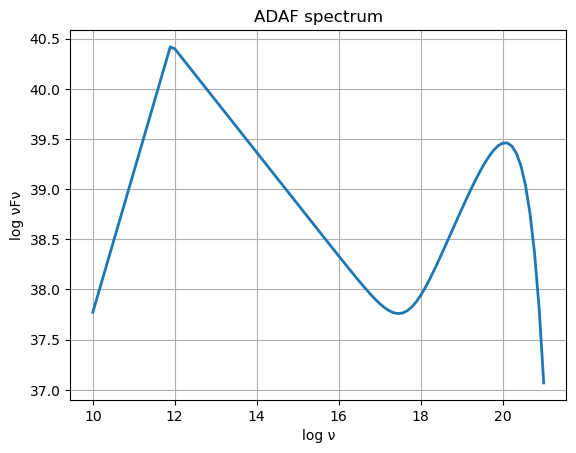

m = 1000000000.0
mdot = 0.0003

=== OUTPUT ===
teta = 5569393486.477101
xm   = 843.1034728857318
f    = 0.9979184166708818
10.0 37.5812253908619
10.11111111111111 37.73678094614384
10.222222222222221 37.89233650145239
10.333333333333334 38.047892056784974
10.444444444444445 38.20344761213924
10.555555555555555 38.35900316751309
10.666666666666666 38.51455872290462
10.777777777777779 38.6701142783121
10.88888888888889 38.82566983373398
11.0 38.98122538916887
11.11111111111111 39.136780944615495
11.222222222222221 39.29233650007272
11.333333333333334 39.447892055539505
11.444444444444445 39.60344761101493
11.555555555555555 39.75900316649815
11.666666666666666 39.9145587219884
11.777777777777779 40.070114277485004
11.88888888888889 40.01425358834028
12.0 39.93814056416598
12.11111111111111 39.86202754014299
12.222222222222221 39.78591451637317
12.333333333333332 39.7098014930192
12.444444444444445 39.63368847033906
12.555555555555555 39.557575448739684
12.666666666666666 39.4814624288600

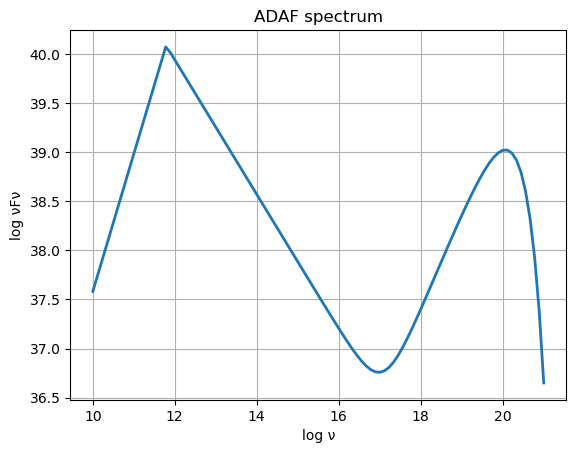

In [32]:
specdata(1e9, 5.7e-3, 0.5)  #m, mdot, beta
specdata(1e9, 0.5e-3, 0.5)
specdata(1e9, 0.3e-3, 0.5)